## 1. 変数データの歪み（Skewness）

年収データで、大部分が低い年収帯に集中しており、一部に高年収者が存在する場合、
一部の高年収者によって<strong>平均値が右側に引っ張られる</strong>。

-> <strong>平均値 vs 中央値：</strong> 平均値 ＞ 中央値 となる傾向がある。

-> データの大部分は左側に集中し、右側に長い裾が伸びた形になる（<strong>Right-Skewed</strong>）。

<img src="../images/image-71_1.png" width="700">

<br>

## 2. 一方に偏ったデータの問題点

- <strong>外れ値（Outlier）の影響</strong> <br> 
一方に偏ったデータでは、一部の非常に大きな値が平均・分散・回帰モデルなどに<strong>過度に大きな影響</strong>を与える。

- <strong>統計・機械学習モデルの性能が不安定になる</strong>  
データの歪みが大きいと、モデルが一般的なパターンを十分に学習できず、<strong>特定の外れ値に過学習する</strong>リスクが高くなる。

<br>

## 3. 解決策：分布変換（Box-Cox・Yeo-Johnson Transformation）

- 外れ値のデータを削除せず、そのまま保持する。
- 全体的な数値の大きさや分布の形を変換し、<strong>外れ値の相対的な影響や歪みを小さくする</strong>。
- 元の年収データと変換後のデータは<strong>同じ対象・同じ情報</strong>を表しているが、表示される数値のスケールは異なる。

#### 例）

$2,800（元の年収値） → -1.707895（変換後の値）

2つは異なるデータではなく、<strong>同じ人の年収を別のスケールで表した変換値</strong>である。

<br>

<strong>※ Box-Cox vs Yeo-Johnson</strong>

<p style="color:#ff0000;">
<strong>Box-Cox（1964年）</strong>：正の値のデータのみ処理可能
</p>

<p style="color:#ff0000;">
<strong>Yeo-Johnson（2000年）</strong>：0や負の値を含むデータも処理可能
</p>

<br>

<p style="color:#1683e8;">
※ 機械学習の学習時には、必要に応じて<strong>分布変換した変数</strong>を活用できる。
</p>

<p style="color:#1683e8;">
分布変換を適用したからといって、モデルの性能が必ず向上するわけではない。
（データの特徴やモデルのアルゴリズムによって異なる）
</p>

<br>

### # Box-Cox変換を用いて、年収データの歪みを調整し、変換前後の分布を比較する。

(今回の `salary` データはすべて正の値であるため、**Box-CoxとYeo-Johnsonの両方を適用できる**。
ただし、変換方法が異なるため、**変換後の値が完全に同じになるとは限らない**。)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer

<br>

#### 1. 30人の会社員の年収データ

In [3]:
df = pd.DataFrame({
    'salary': [
        2800, 2900, 3000, 3100, 3200,
        3300, 3400, 3500, 3600, 3700,
        3800, 3900, 4000, 4100, 4200,
        4300, 4500, 4700, 4900, 5200,
        5500, 5800, 6200, 6800, 7500,
        8500, 10000, 12000, 15000, 20000
    ]
})

<br>

#### 2. 変換前のデータ確認

In [4]:
print("平均 :", df['salary'].mean())
print("中央値 :", df['salary'].median())

平均 : 5780.0
中央値 : 4250.0


<br>

#### 3. 変換前のヒストグラム

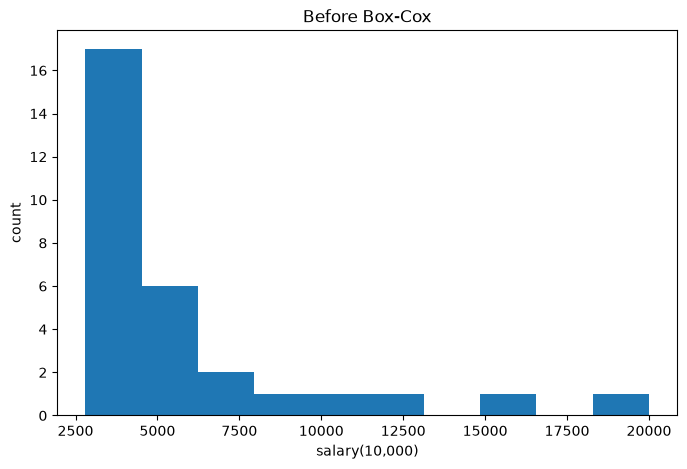

In [5]:
plt.figure(figsize=(8, 5))

plt.hist(df['salary'], bins=10)

plt.xlabel('salary(10,000)')
plt.ylabel('count')
plt.title('Before Box-Cox')

plt.show()

<br>

#### 4. Box-Cox変換

In [6]:
pt = PowerTransformer(method='box-cox')
# pt = PowerTransformer(method='yeo-johnson')

salary_boxcox = pt.fit_transform(df[['salary']])

# 変換結果を新しい列として追加
df['salary_boxcox'] = salary_boxcox

<br>

#### 5. 変換後のデータ確認

In [7]:
display(df)

,salary,salary_boxcox
0,2800,-1.707895
1,2900,-1.543160
2,3000,-1.390453
3,3100,-1.248537
4,3200,-1.116338
5,3300,-0.992917
6,3400,-0.877450
7,3500,-0.769213
8,3600,-0.667566
9,3700,-0.571940


※ `PowerTransformer`はデフォルトで標準化も行うため、変換後の値は平均0を基準として負の値や正の値になる。

- **負の値** → 変換後の平均より相対的に小さい値
- **0付近** → 変換後の平均付近
- **正の値** → 変換後の平均より相対的に大きい値

<br>

#### 6. 変換後のヒストグラム

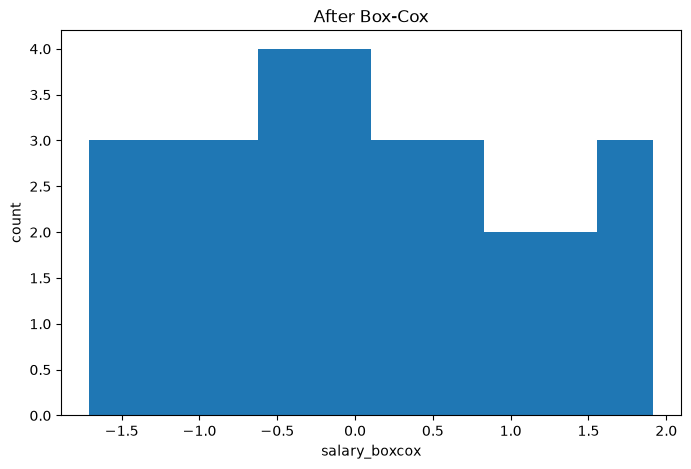

In [8]:
plt.figure(figsize=(8, 5))

plt.hist(df['salary_boxcox'], bins=10)

plt.xlabel('salary_boxcox')
plt.ylabel('count')
plt.title('After Box-Cox')

plt.show()

<br>

→ ヒストグラムを確認すると、分布が変化していることが分かる。

<img src="../images/image-71_2.png" width="600">

<br>

### # Yeo-Johnson変換の前後で線形回帰モデルの性能と特徴量の分布を比較する。

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import r2_score

<br>

#### 1. 実際のサンプルデータを定義（NumPy不使用）

In [5]:
df = pd.DataFrame({
    'X1': [
        1.1, 1.2, 1.3, 1.5, 1.8, 2.0, 2.3, 2.7, 3.0, 3.5,
        4.0, 5.2, 6.8, 9.0, 12.5, 18.0, 25.0, 40.0, 75.0, 150.0,
        1.0, 1.4, 1.6, 2.1, 2.5, 3.2, 4.5, 7.5, 15.0, 35.0,
        1.2, 1.7, 2.2, 2.9, 3.8, 5.5, 8.5, 20.0, 50.0, 110.0
    ],
    'X2': [
        0.5, 0.8, 1.1, 1.4, 2.0, 2.5, 3.2, 4.0, 5.5, 7.0,
        10.0, 14.0, 22.0, 35.0, 60.0, 95.0, 140.0, 230.0, 400.0, 800.0,
        0.6, 1.0, 1.3, 1.8, 2.8, 4.8, 8.0, 18.0, 45.0, 100.0,
        0.7, 1.2, 1.9, 3.0, 5.0, 9.0, 16.0, 30.0, 80.0, 200.0
    ],
    'y': [
        12.1, 13.5, 14.2, 15.8, 17.1, 18.3, 19.5, 21.0, 22.4, 24.1,
        25.8, 28.2, 31.0, 34.2, 37.9, 41.5, 45.1, 50.3, 57.8, 66.2,
        11.5, 15.1, 16.2, 18.7, 20.5, 23.0, 27.1, 32.5, 39.1, 48.0,
        13.0, 16.5, 19.0, 21.8, 24.9, 28.8, 33.0, 42.1, 52.0, 62.5
    ]
})

<br>

#### 2. X・yを分離し、学習データとテストデータに分割

In [6]:
X = df[['X1', 'X2']]
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

<br>

#### 3. 元のデータで線形回帰（LinearRegression）

In [7]:
print("\n===== 1. 元のデータ（LinearRegression） =====")

lr = LinearRegression()
lr.fit(X_train, y_train)

print("傾き a :", lr.coef_)
print("切片 b :", lr.intercept_)

pred_lr = lr.predict(X_test)

r2_original = r2_score(y_test, pred_lr)

print("決定係数 R² :", round(r2_original, 4))


===== 1. 元のデータ（LinearRegression） =====
傾き a : [ 0.82539962 -0.03674495]
切片 b : 18.77994305448621
決定係数 R² : -0.5109


<br>

#### 4. Yeo-Johnson変換

In [8]:
pt = PowerTransformer(method='yeo-johnson')

X_train_yj = pt.fit_transform(X_train)
X_test_yj = pt.transform(X_test)

<br>

#### 5. Yeo-Johnson変換後のデータで線形回帰（LinearRegression）

In [9]:
print("\n===== 2. Yeo-Johnson変換後（LinearRegression） =====")

lr_yj = LinearRegression()
lr_yj.fit(X_train_yj, y_train)

print("傾き a :", lr_yj.coef_)
print("切片 b :", lr_yj.intercept_)

pred_yj = lr_yj.predict(X_test_yj)

r2_yj = r2_score(y_test, pred_yj)

print("決定係数 R² :", round(r2_yj, 4))


===== 2. Yeo-Johnson変換後（LinearRegression） =====
傾き a : [17.25065835 -4.69453564]
切片 b : 26.05714285714285
決定係数 R² : 0.8291


→ 変換前後のR²を比較することで、Yeo-Johnson変換が線形回帰モデルの性能に与えた影響を確認できる。

<br>

#### 6. 分布変換前後のヒストグラムを比較

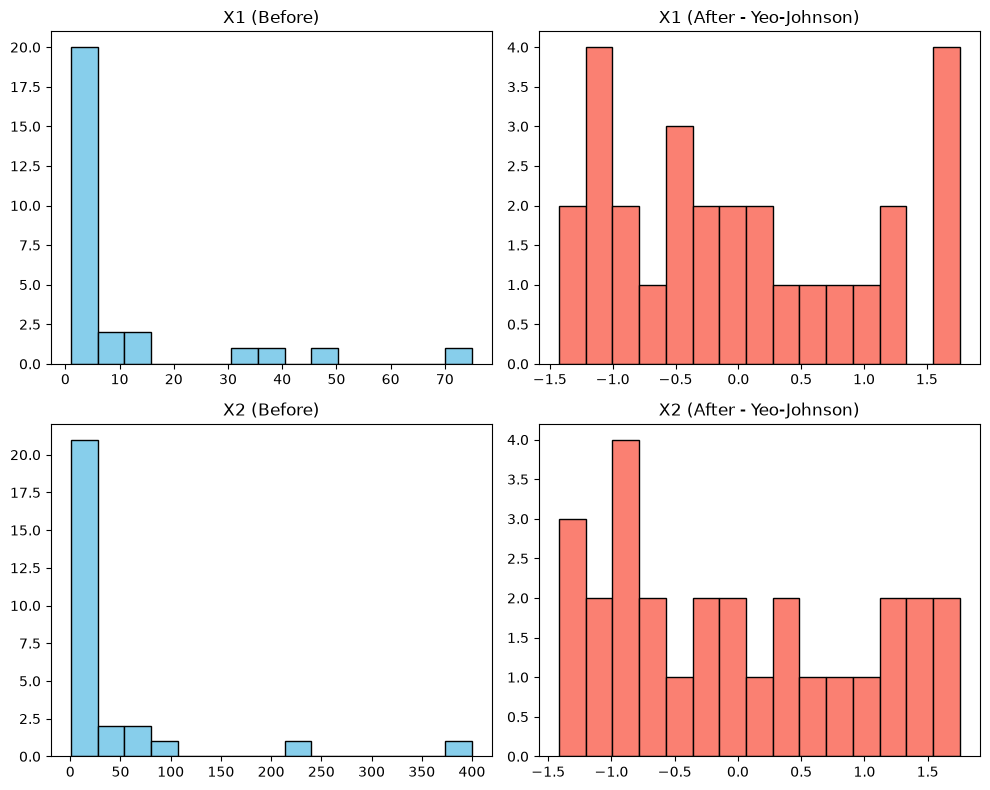

In [10]:
# 変換後のデータを確認しやすいようにDataFrameへ変換
X_train_yj_df = pd.DataFrame(X_train_yj, columns=['X1', 'X2'])

fig = plt.figure(figsize=(10, 8))

axes1 = fig.add_subplot(2, 2, 1)
axes2 = fig.add_subplot(2, 2, 2)
axes3 = fig.add_subplot(2, 2, 3)
axes4 = fig.add_subplot(2, 2, 4)

# X1：変換前 / 変換後
axes1.hist(X_train['X1'], bins=15, color='skyblue', edgecolor='black')
axes1.set_title('X1 (Before)')

axes2.hist(X_train_yj_df['X1'], bins=15, color='salmon', edgecolor='black')
axes2.set_title('X1 (After - Yeo-Johnson)')

# X2：変換前 / 変換後
axes3.hist(X_train['X2'], bins=15, color='skyblue', edgecolor='black')
axes3.set_title('X2 (Before)')

axes4.hist(X_train_yj_df['X2'], bins=15, color='salmon', edgecolor='black')
axes4.set_title('X2 (After - Yeo-Johnson)')

plt.tight_layout()
plt.show()

→ Yeo-Johnson変換によってX1・X2の歪みが緩和され、変換前よりも分布の偏りが小さくなっていることが分かる。

<br>

<p style="color:#ff0000; font-weight:700;">
※ この例では、分布変換後にモデル性能が向上するようなサンプルデータを生成して使用している。実際には、分布変換を適用したからといってモデルの性能が必ず向上するわけではない。
</p>

<div style="display:inline-block; min-width:720px; font-family:Consolas, 'Yu Gothic', monospace; line-height:27px; margin:4px 0 14px 0; color:#222;"><div style="background:#e7e9eb; padding:0 14px;"><span style="color:#c78b55;">=====</span> <span style="color:#ff5a1f;">1.</span> 元の <span style="color:#ff4d6d;">データ</span>（LinearRegression）<span style="color:#c78b55;">=====</span></div><div style="background:#f4f5f6; padding:0 14px;">決定係数 <span style="color:#ff5a1f;">R²</span>：<span style="color:#ff5a1f;">-0.5109</span></div><div style="background:#e7e9eb; padding:0 14px;">&nbsp;</div><div style="background:#f4f5f6; padding:0 14px;"><span style="color:#c78b55;">=====</span> <span style="color:#ff5a1f;">2.</span> Yeo-Johnson 変換<span style="color:#ff4d6d;">後</span>（LinearRegression）<span style="color:#c78b55;">=====</span></div><div style="background:#e7e9eb; padding:0 14px;">決定係数 <span style="color:#ff5a1f;">R²</span>：<span style="color:#ff5a1f;">0.8291</span></div></div>